# 🎸 Tensión en cuerdas de guitarra — Variación por giro de clavija

## Descripción del experimento

Se utilizan las **6 cuerdas** de una guitarra. Para cada cuerda se gira la clavija a distintos ángulos acumulados y se cuelga **la misma masa** `m` en el centro de la cuerda, registrando el desplazamiento vertical `y` resultante.

| Ángulo de clavija | Descripción |
|---|---|
| 0° | Cuerda afinada (referencia) |
| +90° | Tensionada 90° respecto a la afinación |
| +180° | Tensionada 180° respecto a la afinación |
| −90° | Destensionada 90° respecto a la afinación |
| −180° | Destensionada 180° respecto a la afinación |

## Marco teórico

Al colgar la masa en el centro, la cuerda adopta forma de **"V"**. Con longitud de escala `L` y desplazamiento vertical `y`:

$$\theta = \arctan\!\left(\frac{2y}{L}\right)$$

$$\Delta L = 2\sqrt{\left(\frac{L}{2}\right)^2 + y^2} - L$$

Equilibrio de fuerzas verticales:

$$\boxed{T = \frac{mg}{2\sin(\theta)}}$$

---
**Lógica física:** a mayor tensión en la cuerda → menor `y` al colgar el mismo peso → mayor `T` calculada.

---
## Celda 1 – Importación de librerías

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans'
})

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


---
## Celda 2 – Parámetros físicos

> **Instrucción:** Ajusta `L` si la longitud vibrante de tu guitarra es diferente a 65 cm.

In [31]:
# ============================================================
# PARÁMETROS FÍSICOS
# ============================================================

L = 0.65   # [m] Longitud vibrante de la cuerda (distancia cejuela–puente)
g = 9.81   # [m/s²] Aceleración gravitacional

# Ángulos de clavija analizados (en orden de columna del CSV)
ANGULOS       = [0, 90, 180, -90, -180]          # grados
ETIQUETAS_ANG = ['0°', '+90°', '+180°', '−90°', '−180°']

# Nombres de las cuerdas (de aguda a grave, notación estándar)
NOMBRES_CUERDAS = {
    1: 'Cuerda 1 (E4 - mi agudo)',
    2: 'Cuerda 2 (B3 - si)',
    3: 'Cuerda 3 (G3 - sol)',
    4: 'Cuerda 4 (D3 - re)',
    5: 'Cuerda 5 (A2 - la)',
    6: 'Cuerda 6 (E2 - mi grave)',
}

print(f'📐 Longitud vibrante:  L = {L*100:.1f} cm')
print(f'🌍 Gravedad:           g = {g} m/s²')
print(f'📐 Ángulos analizados: {ANGULOS}')

📐 Longitud vibrante:  L = 65.0 cm
🌍 Gravedad:           g = 9.81 m/s²
📐 Ángulos analizados: [0, 90, 180, -90, -180]


---
## Celda 3 – Lectura del CSV

### Formato requerido del archivo CSV

**Nombre del archivo:** `datos_cuerdas.csv`  
**Separador:** punto y coma (`;`)  
**Decimal:** punto (`.`)

```
cuerda;masa_kg;y_0_m;y_90_m;y_180_m;y_n90_m;y_n180_m
1;0.250;0.0085;0.0060;0.0045;0.0110;0.0145
2;0.250;0.0072;0.0051;0.0038;0.0095;0.0130
3;0.250;0.0068;0.0048;0.0035;0.0090;0.0122
4;0.250;0.0061;0.0043;0.0031;0.0082;0.0115
5;0.250;0.0055;0.0039;0.0028;0.0074;0.0105
6;0.250;0.0048;0.0034;0.0024;0.0066;0.0095
```

**Descripción de columnas:**

| Columna | Descripción | Unidades |
|---|---|---|
| `cuerda` | Número de cuerda (1 = mi agudo … 6 = mi grave) | — |
| `masa_kg` | Masa colgada (la misma para todas las mediciones) | kg |
| `y_0_m` | Desplazamiento con clavija a 0° (afinada) | m |
| `y_90_m` | Desplazamiento con clavija a +90° | m |
| `y_180_m` | Desplazamiento con clavija a +180° | m |
| `y_n90_m` | Desplazamiento con clavija a −90° | m |
| `y_n180_m` | Desplazamiento con clavija a −180° | m |

> ⚠️ **Nota:** Si mediste en centímetros, cambia la columna `y_n90_m` → divide entre 100 en la celda de conversión (Celda 4).

In [32]:
# ============================================================
# LECTURA DEL CSV  —  versión robusta (autodetecta separador)
# ============================================================

ARCHIVO = 'datos_cuerdas.csv'   # ← Cambia si es necesario

COLS_REQUERIDAS = ['cuerda', 'masa_kg', 'y_0_m', 'y_90_m', 'y_180_m', 'y_n90_m', 'y_n180_m']
COLS_Y          = ['y_0_m', 'y_90_m', 'y_180_m', 'y_n90_m', 'y_n180_m']

def leer_csv_robusto(path):
    """Intenta leer el CSV probando ; y , como separador.
    Limpia espacios en nombres de columna y devuelve el DataFrame."""
    for sep in [';', ',', '\t']:
        try:
            tmp = pd.read_csv(
                path, sep=sep, decimal='.',
                comment='#', skip_blank_lines=True,
                skipinitialspace=True
            )
            tmp.columns = tmp.columns.str.strip()   # elimina espacios en cabecera
            if 'cuerda' in tmp.columns:
                return tmp, sep
        except Exception:
            continue
    raise ValueError(f"No se pudo leer '{path}' con separadores ; , o tabulador.")

try:
    df_raw, sep_detectado = leer_csv_robusto(ARCHIVO)
    df_raw['cuerda'] = df_raw['cuerda'].astype(int)
    df_raw = df_raw.sort_values('cuerda').reset_index(drop=True)

    # Verificar que estén todas las columnas
    faltantes = [c for c in COLS_REQUERIDAS if c not in df_raw.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas en el CSV: {faltantes}\n"
                         f"Columnas encontradas: {df_raw.columns.tolist()}")

    print(f"✅ Archivo '{ARCHIVO}' leído correctamente (separador detectado: '{sep_detectado}').")
    print(f"   Cuerdas registradas: {df_raw['cuerda'].tolist()}")
    print(f"   Masa utilizada:      {df_raw['masa_kg'].unique()} kg\n")
    print(df_raw.to_string(index=False))

except FileNotFoundError:
    print(f"⚠️  Archivo '{ARCHIVO}' no encontrado.")
    print("   Se cargan datos de demostración para continuar.\n")

    demo = {
        'cuerda':   [1,      2,      3,      4,      5,      6     ],
        'masa_kg':  [0.250,  0.250,  0.250,  0.250,  0.250,  0.250 ],
        'y_0_m':    [0.0085, 0.0072, 0.0068, 0.0061, 0.0055, 0.0048],
        'y_90_m':   [0.0060, 0.0051, 0.0048, 0.0043, 0.0039, 0.0034],
        'y_180_m':  [0.0045, 0.0038, 0.0035, 0.0031, 0.0028, 0.0024],
        'y_n90_m':  [0.0110, 0.0095, 0.0090, 0.0082, 0.0074, 0.0066],
        'y_n180_m': [0.0145, 0.0130, 0.0122, 0.0115, 0.0105, 0.0095],
    }
    df_raw = pd.DataFrame(demo)
    print('📋 Datos de demostración cargados:')
    print(df_raw.to_string(index=False))

except ValueError as e:
    print(f"❌ Error al leer el archivo:\n   {e}")
    print("\n🔍 Diagnóstico — primeras líneas del archivo tal como están en disco:")
    with open(ARCHIVO, 'r', encoding='utf-8', errors='replace') as f:
        for i, linea in enumerate(f):
            if i >= 6:
                break
            print(f"   Línea {i}: {repr(linea)}")

✅ Archivo 'datos_cuerdas.csv' leído correctamente (separador detectado: ',').
   Cuerdas registradas: [1, 2, 3, 4, 5, 6]
   Masa utilizada:      [0.1515] kg

 cuerda  masa_kg    y_0_m   y_90_m  y_180_m  y_n90_m  y_n180_m
      1   0.1515 0.003366 0.003240 0.003081 0.003939  0.004119
      2   0.1515 0.004875 0.004371 0.004265 0.005114  0.005282
      3   0.1515 0.004710 0.004290 0.004039 0.004900  0.005170
      4   0.1515 0.003679 0.003449 0.003410 0.004091  0.004260
      5   0.1515 0.003605 0.003417 0.003350 0.004071  0.004156
      6   0.1515 0.003883 0.003614 0.003344 0.004160  0.004400


---
## Celda 4 – Conversión de unidades (si mediste en cm)

> Si ya ingresaste los valores en metros en el CSV, esta celda no hace nada. Si los ingresaste en **centímetros**, activa la conversión descomentando la línea.

In [33]:
# ============================================================
# CONVERSIÓN DE UNIDADES
# ============================================================

# Descomenta la línea siguiente si tus y están en CENTÍMETROS:
# df_raw[COLS_Y] = df_raw[COLS_Y] / 100.0

# Validación física: 0 < y < L/2
for col in COLS_Y:
    assert (df_raw[col] > 0).all(), f'❌ Hay valores nulos o negativos en {col}'
    assert (df_raw[col] < L/2).all(), f'❌ Valor en {col} supera L/2 = {L/2:.3f} m (imposible geométricamente)'

print('✅ Validación física superada — todos los desplazamientos son físicamente posibles.')
print(f'   Rango permitido: 0 < y < {L/2*100:.1f} cm')

✅ Validación física superada — todos los desplazamientos son físicamente posibles.
   Rango permitido: 0 < y < 32.5 cm


---
## Celda 5 – Cálculo de θ, T y ΔL para todas las cuerdas y ángulos

In [34]:
# ============================================================
# FUNCIÓN DE CÁLCULO CENTRAL
# ============================================================

def calcular_tension(y, m, L, g):
    """Dado desplazamiento y [m], masa m [kg], longitud L [m],
    devuelve (theta_rad, theta_deg, T_N, delta_L_mm)."""
    theta_rad  = np.arctan(2 * y / L)
    theta_deg  = np.degrees(theta_rad)
    T          = (m * g) / (2 * np.sin(theta_rad))
    delta_L    = 2 * np.sqrt((L / 2)**2 + y**2) - L  # [m]
    return theta_rad, theta_deg, T, delta_L * 1000     # ΔL en mm


# ============================================================
# CALCULAR PARA TODAS LAS CUERDAS Y TODOS LOS ÁNGULOS
# ============================================================

# Mapeamos cada columna de y a su ángulo de clavija
col_angulo = dict(zip(COLS_Y, ETIQUETAS_ANG))

registros = []

for _, fila in df_raw.iterrows():
    c = int(fila['cuerda'])
    m_cuerda = fila['masa_kg']
    for col, etiq in col_angulo.items():
        y_val = fila[col]
        tr, td, T, dL = calcular_tension(y_val, m_cuerda, L, g)
        registros.append({
            'cuerda'      : c,
            'angulo'      : etiq,
            'masa_kg'     : m_cuerda,
            'y_m'         : y_val,
            'y_cm'        : y_val * 100,
            'theta_deg'   : td,
            'T_N'         : T,
            'deltaL_mm'   : dL,
        })

df_res = pd.DataFrame(registros)

# Orden correcto de ángulos
orden_ang = ['−180°', '−90°', '0°', '+90°', '+180°']
df_res['angulo'] = pd.Categorical(df_res['angulo'], categories=orden_ang, ordered=True)
df_res = df_res.sort_values(['cuerda', 'angulo']).reset_index(drop=True)

print('✅ Cálculos completados.\n')
print(df_res[['cuerda','angulo','y_cm','theta_deg','T_N','deltaL_mm']]
      .rename(columns={'y_cm':'y [cm]','theta_deg':'θ [°]','T_N':'T [N]','deltaL_mm':'ΔL [mm]'})
      .round(4)
      .to_string(index=False))

✅ Cálculos completados.

 cuerda angulo  y [cm]  θ [°]   T [N]  ΔL [mm]
      1  −180°  0.4119 0.7261 58.6379   0.0522
      1   −90°  0.3939 0.6944 61.3170   0.0477
      1     0°  0.3366 0.5934 71.7537   0.0349
      1   +90°  0.3240 0.5712 74.5438   0.0323
      1  +180°  0.3081 0.5431 78.3904   0.0292
      2  −180°  0.5282 0.9311 45.7292   0.0858
      2   −90°  0.5114 0.9015 47.2311   0.0805
      2     0°  0.4875 0.8594 49.5461   0.0731
      2   +90°  0.4371 0.7705 55.2578   0.0588
      2  +180°  0.4265 0.7519 56.6309   0.0560
      3  −180°  0.5170 0.9114 46.7196   0.0822
      3   −90°  0.4900 0.8638 49.2933   0.0739
      3     0°  0.4710 0.8303 51.2814   0.0683
      3   +90°  0.4290 0.7563 56.3009   0.0566
      3  +180°  0.4039 0.7120 59.7991   0.0502
      4  −180°  0.4260 0.7510 56.6973   0.0558
      4   −90°  0.4091 0.7212 59.0391   0.0515
      4     0°  0.3679 0.6486 65.6497   0.0416
      4   +90°  0.3449 0.6080 70.0271   0.0366
      4  +180°  0.3410 0.6011 70.82

---
## Celda 6 – Tabla resumen: Tensión por cuerda y ángulo de clavija

In [35]:
# ============================================================
# TABLA PIVOTE: filas = cuerdas, columnas = ángulos
# ============================================================

tabla_T = df_res.pivot(index='cuerda', columns='angulo', values='T_N')[orden_ang]
tabla_y = df_res.pivot(index='cuerda', columns='angulo', values='y_cm')[orden_ang]
tabla_dL = df_res.pivot(index='cuerda', columns='angulo', values='deltaL_mm')[orden_ang]

tabla_T.index  = [f'Cuerda {i}' for i in tabla_T.index]
tabla_y.index  = [f'Cuerda {i}' for i in tabla_y.index]
tabla_dL.index = [f'Cuerda {i}' for i in tabla_dL.index]

print('=' * 65)
print('  TENSIÓN T [N]  —  por cuerda y ángulo de clavija')
print('=' * 65)
print(tabla_T.round(2).to_string())
print()
print('=' * 65)
print('  DESPLAZAMIENTO y [cm]')
print('=' * 65)
print(tabla_y.round(4).to_string())
print()
print('=' * 65)
print('  ELONGACIÓN ΔL [mm]')
print('=' * 65)
print(tabla_dL.round(4).to_string())

  TENSIÓN T [N]  —  por cuerda y ángulo de clavija
angulo    −180°   −90°     0°   +90°  +180°
Cuerda 1  58.64  61.32  71.75  74.54  78.39
Cuerda 2  45.73  47.23  49.55  55.26  56.63
Cuerda 3  46.72  49.29  51.28  56.30  59.80
Cuerda 4  56.70  59.04  65.65  70.03  70.83
Cuerda 5  58.12  59.33  67.00  70.68  72.10
Cuerda 6  54.89  58.06  62.20  66.83  72.23

  DESPLAZAMIENTO y [cm]
angulo     −180°    −90°      0°    +90°   +180°
Cuerda 1  0.4119  0.3939  0.3366  0.3240  0.3081
Cuerda 2  0.5282  0.5114  0.4875  0.4371  0.4265
Cuerda 3  0.5170  0.4900  0.4710  0.4290  0.4039
Cuerda 4  0.4260  0.4091  0.3679  0.3449  0.3410
Cuerda 5  0.4156  0.4071  0.3605  0.3417  0.3350
Cuerda 6  0.4400  0.4160  0.3883  0.3614  0.3344

  ELONGACIÓN ΔL [mm]
angulo     −180°    −90°      0°    +90°   +180°
Cuerda 1  0.0522  0.0477  0.0349  0.0323  0.0292
Cuerda 2  0.0858  0.0805  0.0731  0.0588  0.0560
Cuerda 3  0.0822  0.0739  0.0683  0.0566  0.0502
Cuerda 4  0.0558  0.0515  0.0416  0.0366  0.0358
Cuerda

---
## Celda 7 – Gráfica 1: Tensión vs ángulo de clavija por cuerda

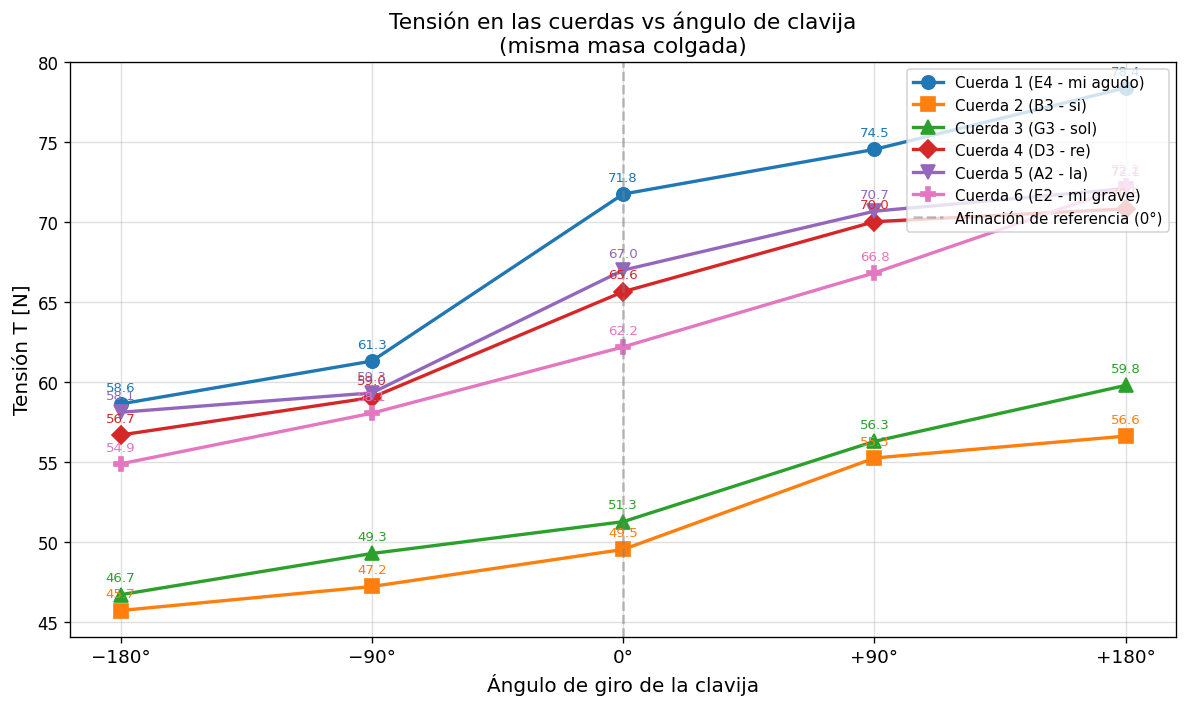

✅ Guardada 'tension_vs_angulo.png'


In [36]:
# ============================================================
# GRÁFICA 1: T vs ángulo de clavija (una línea por cuerda)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

colores = plt.cm.tab10(np.linspace(0, 0.6, 6))
marcadores = ['o', 's', '^', 'D', 'v', 'P']
x_pos = np.arange(len(orden_ang))

for idx, c in enumerate(range(1, 7)):
    sub = df_res[df_res['cuerda'] == c].sort_values('angulo')
    if sub.empty:
        continue
    T_vals = sub['T_N'].values
    ax.plot(x_pos, T_vals,
            color=colores[idx], marker=marcadores[idx],
            linewidth=2, markersize=8, label=NOMBRES_CUERDAS.get(c, f'Cuerda {c}'))
    for xi, Ti in zip(x_pos, T_vals):
        ax.annotate(f'{Ti:.1f}', (xi, Ti),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color=colores[idx])

ax.set_xticks(x_pos)
ax.set_xticklabels(orden_ang, fontsize=11)
ax.set_xlabel('Ángulo de giro de la clavija', fontsize=12)
ax.set_ylabel('Tensión T [N]', fontsize=12)
ax.set_title('Tensión en las cuerdas vs ángulo de clavija\n(misma masa colgada)', fontsize=13)
ax.axvline(x=2, color='gray', linestyle='--', alpha=0.5, label='Afinación de referencia (0°)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('tension_vs_angulo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'tension_vs_angulo.png'")

---
## Celda 8 – Gráfica 2: Barras agrupadas de tensión

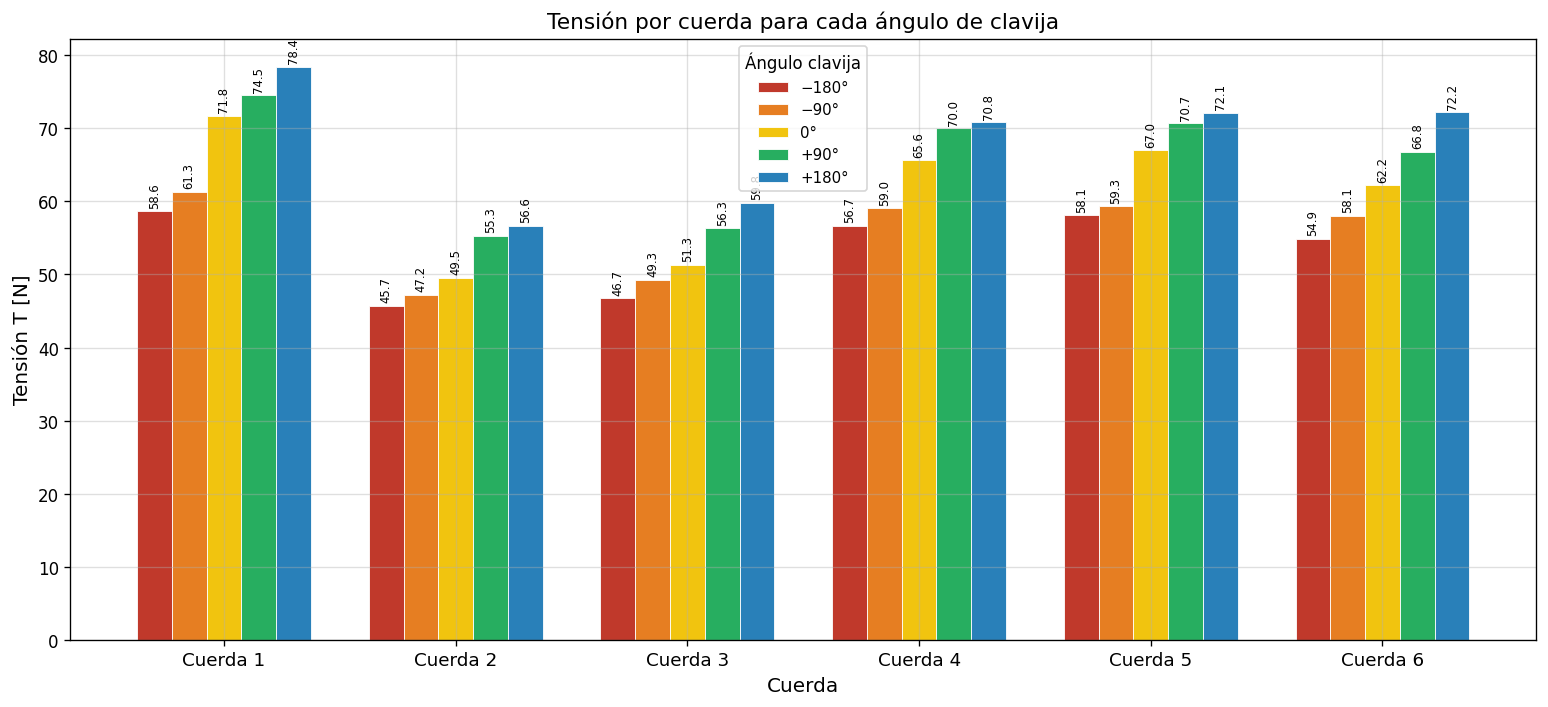

✅ Guardada 'barras_tension.png'


In [37]:
# ============================================================
# GRÁFICA 2: Barras agrupadas por cuerda
# ============================================================

n_cuerdas  = len(df_raw)
n_angulos  = len(orden_ang)
bar_width  = 0.15
x_base     = np.arange(n_cuerdas)

fig, ax = plt.subplots(figsize=(13, 6))

paleta = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#2980b9']

for i, ang in enumerate(orden_ang):
    offset = (i - n_angulos / 2 + 0.5) * bar_width
    vals = tabla_T[ang].values
    bars = ax.bar(x_base + offset, vals, width=bar_width,
                  label=ang, color=paleta[i], edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x_base)
ax.set_xticklabels([f'Cuerda {i+1}' for i in range(n_cuerdas)], fontsize=11)
ax.set_xlabel('Cuerda', fontsize=12)
ax.set_ylabel('Tensión T [N]', fontsize=12)
ax.set_title('Tensión por cuerda para cada ángulo de clavija', fontsize=13)
ax.legend(title='Ángulo clavija', fontsize=9)
plt.tight_layout()
plt.savefig('barras_tension.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'barras_tension.png'")

---
## Celda 9 – Gráfica 3: Panel individual por cuerda (T vs y)

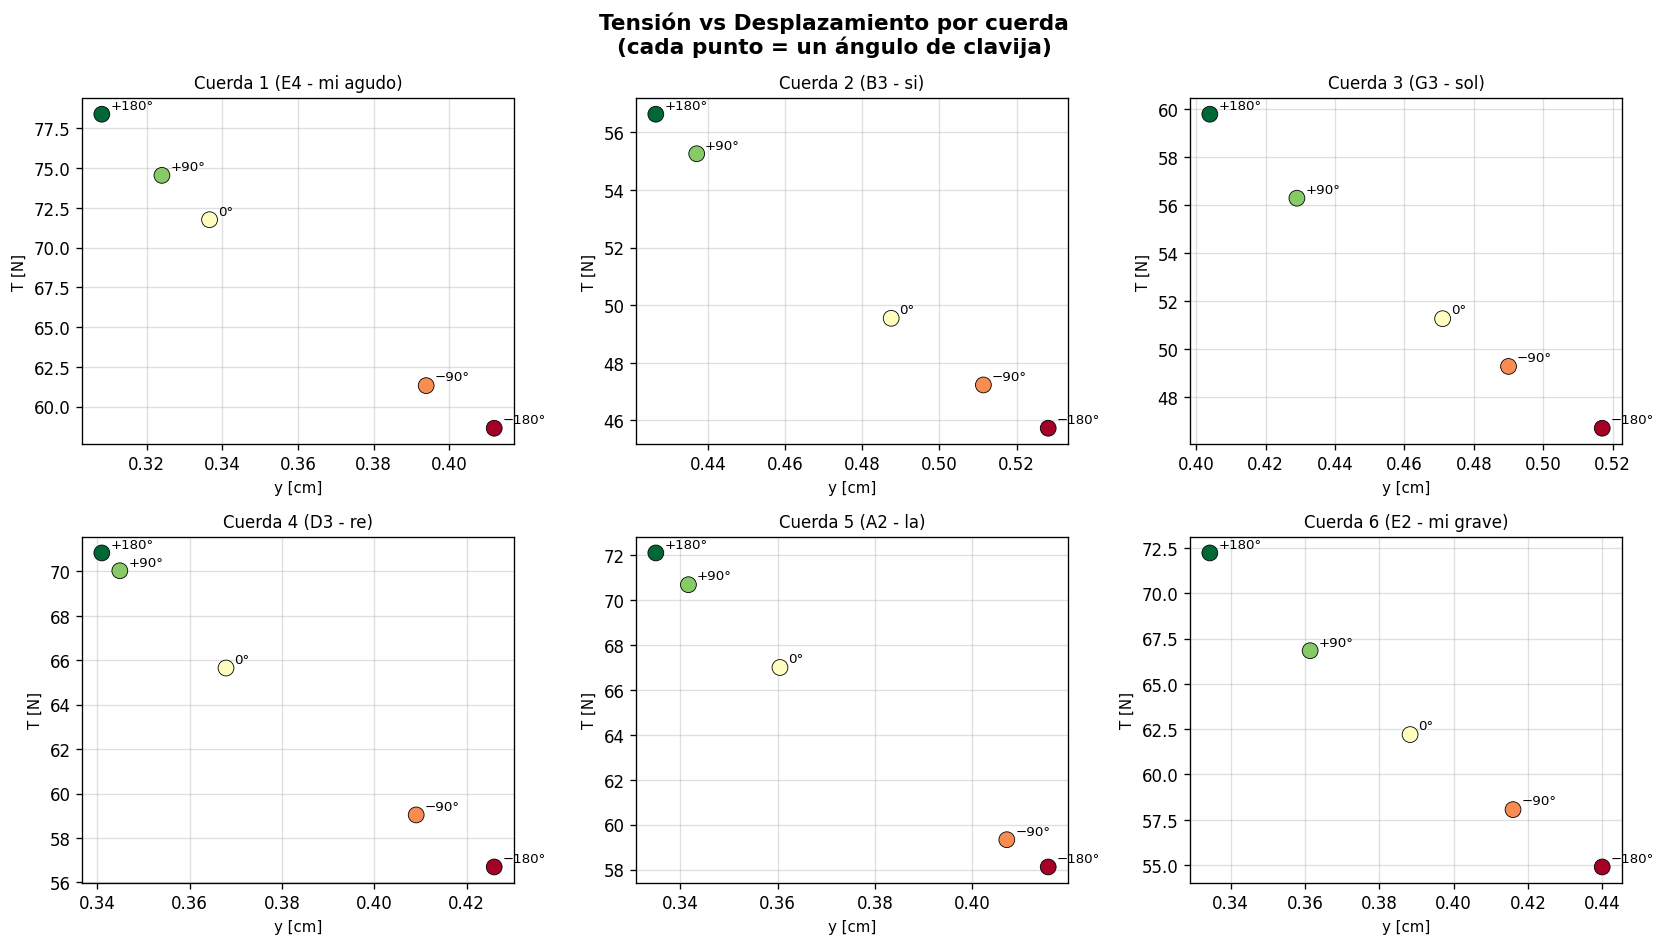

✅ Guardada 'panel_T_vs_y.png'


In [38]:
# ============================================================
# GRÁFICA 3: Panel 2x3 — T vs y para cada cuerda
# Los 5 puntos de cada cuerda muestran la relación T-y
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Tensión vs Desplazamiento por cuerda\n(cada punto = un ángulo de clavija)',
             fontsize=13, fontweight='bold')

for idx, c in enumerate(range(1, 7)):
    ax = axes[idx // 3][idx % 3]
    sub = df_res[df_res['cuerda'] == c].sort_values('y_cm')

    sc = ax.scatter(sub['y_cm'], sub['T_N'],
                    c=range(len(sub)), cmap='RdYlGn_r',
                    s=90, edgecolors='black', linewidths=0.5, zorder=5)

    for _, row in sub.iterrows():
        ax.annotate(row['angulo'], (row['y_cm'], row['T_N']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

    ax.set_title(NOMBRES_CUERDAS.get(c, f'Cuerda {c}'), fontsize=10)
    ax.set_xlabel('y [cm]', fontsize=9)
    ax.set_ylabel('T [N]', fontsize=9)

plt.tight_layout()
plt.savefig('panel_T_vs_y.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'panel_T_vs_y.png'")

---
## Celda 10 – Variación relativa de tensión respecto a la afinación (0°)

Variación porcentual de T respecto a la afinación de referencia (0°):
angulo    −180°   −90°   0°   +90°  +180°
Cuerda 1 -18.28 -14.55  0.0   3.89   9.25
Cuerda 2  -7.70  -4.67  0.0  11.53  14.30
Cuerda 3  -8.90  -3.88  0.0   9.79  16.61
Cuerda 4 -13.64 -10.07  0.0   6.67   7.89
Cuerda 5 -13.26 -11.45  0.0   5.50   7.61
Cuerda 6 -11.75  -6.66  0.0   7.44  16.12

Interpretación: positivo → más tensión que afinada | negativo → menos tensión


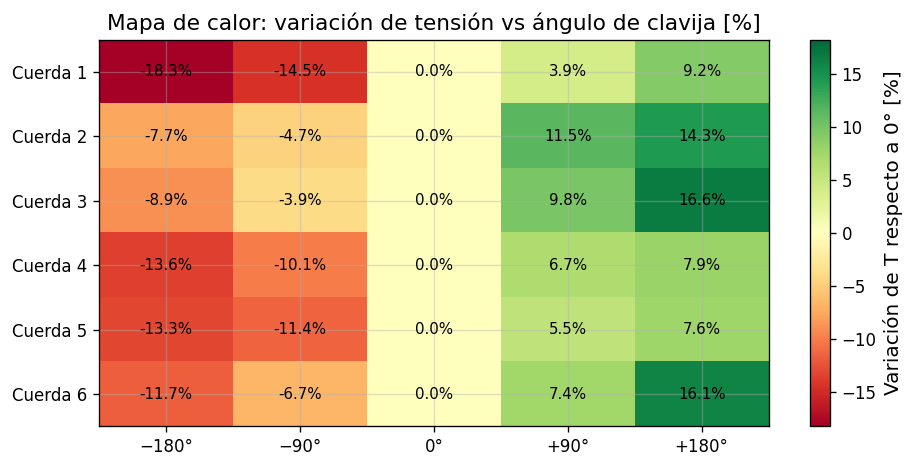

✅ Guardada 'heatmap_variacion.png'


In [39]:
# ============================================================
# VARIACIÓN PORCENTUAL RESPECTO A T(0°)
# ============================================================

T_ref = tabla_T['0°'].values  # T en estado afinado para cada cuerda

tabla_var = tabla_T.copy()
for ang in orden_ang:
    tabla_var[ang] = ((tabla_T[ang].values - T_ref) / T_ref) * 100

print('Variación porcentual de T respecto a la afinación de referencia (0°):')
print(tabla_var.round(2).to_string())
print()
print('Interpretación: positivo → más tensión que afinada | negativo → menos tensión')

# Gráfica de calor (heatmap)
fig, ax = plt.subplots(figsize=(8, 4))
data_hm = tabla_var.values.astype(float)
im = ax.imshow(data_hm, cmap='RdYlGn', aspect='auto',
               vmin=-data_hm.__abs__().max(), vmax=data_hm.__abs__().max())
plt.colorbar(im, ax=ax, label='Variación de T respecto a 0° [%]')

ax.set_xticks(range(len(orden_ang)))
ax.set_xticklabels(orden_ang)
ax.set_yticks(range(len(tabla_var)))
ax.set_yticklabels(tabla_var.index)
ax.set_title('Mapa de calor: variación de tensión vs ángulo de clavija [%]')

# Anotar valores
for i in range(data_hm.shape[0]):
    for j in range(data_hm.shape[1]):
        ax.text(j, i, f'{data_hm[i,j]:.1f}%',
                ha='center', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('heatmap_variacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada 'heatmap_variacion.png'")

---
## Celda 11 – Exportar resultados a CSV

In [40]:
# ============================================================
# EXPORTAR TABLA COMPLETA DE RESULTADOS
# ============================================================

df_export = df_res[['cuerda','angulo','masa_kg','y_cm','theta_deg','T_N','deltaL_mm']].copy()
df_export.columns = ['cuerda','angulo_clavija','masa_kg','y_cm','theta_grados','T_N','deltaL_mm']
df_export.to_csv('resultados_cuerdas.csv', index=False, float_format='%.6f')

print('✅ Resultados detallados guardados en resultados_cuerdas.csv')
print()

# Tabla pivote de tensiones
tabla_T.round(4).to_csv('tabla_tensiones.csv')
print('✅ Tabla de tensiones guardada en tabla_tensiones.csv')
print()
print('Vista previa de la tabla de tensiones [N]:')
print(tabla_T.round(2).to_string())

✅ Resultados detallados guardados en resultados_cuerdas.csv

✅ Tabla de tensiones guardada en tabla_tensiones.csv

Vista previa de la tabla de tensiones [N]:
angulo    −180°   −90°     0°   +90°  +180°
Cuerda 1  58.64  61.32  71.75  74.54  78.39
Cuerda 2  45.73  47.23  49.55  55.26  56.63
Cuerda 3  46.72  49.29  51.28  56.30  59.80
Cuerda 4  56.70  59.04  65.65  70.03  70.83
Cuerda 5  58.12  59.33  67.00  70.68  72.10
Cuerda 6  54.89  58.06  62.20  66.83  72.23


---
## Celda 12 – Conclusiones

### Interpretación física

1. **Tensionar (+90°, +180°):** Al girar la clavija en sentido de tensionado, la cuerda se acorta en el clavijero, aumentando la tensión. Esto se refleja en un **menor desplazamiento `y`** al colgar la misma masa, y por tanto una **mayor T calculada**.

2. **Destensionar (−90°, −180°):** El giro inverso aumenta la longitud libre de la cuerda, reduciéndose la tensión. Se obtiene **mayor `y`** y **menor T**.

3. **Comparación entre cuerdas:** Las cuerdas graves (5, 6) tienen mayor masa lineal y distintas propiedades elásticas, por lo que su tensión a la misma afinación difiere de las cuerdas agudas.

### Posibles fuentes de error
- El giro de la clavija no es perfectamente reproducible (tolerancia del ángulo real).
- Rozamiento en la cejuela o el puente que redistribuye la tensión de forma no uniforme a lo largo de la cuerda.
- La hipótesis `L = constante` asume que la longitud vibrante no cambia al girar la clavija, lo cual es válido si la cuerda no se desplaza lateralmente en la cejuela.